<a href="https://colab.research.google.com/github/Akshay1726/akshay/blob/main/Intern_pro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("/content/kc_house_data.csv")

In [ ]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
print(df.isnull().sum())

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [ ]:
df = df.drop_duplicates()

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

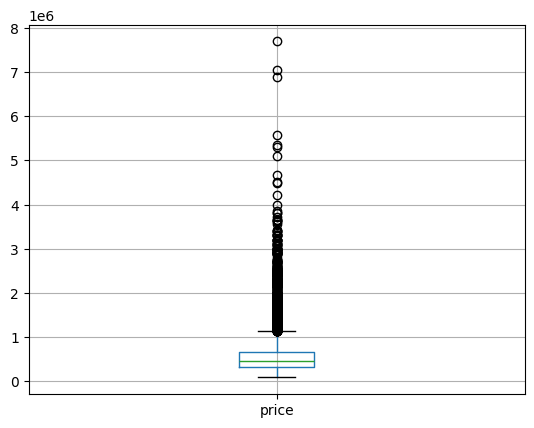

In [ ]:

    import matplotlib.pyplot as plt
    df.boxplot(column=['price'])
    plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# For demonstration, we'll create a 'price_category' for classification using quantiles
df['price_category'] = pd.qcut(df['price'], q=3, labels=['low', 'medium', 'high'])

# Encode the categorical target column to numeric values for SMOTE
df['price_category_encoded'] = df['price_category'].astype('category').cat.codes

# Define features and target for SMOTE
X = df.drop(columns=['id', 'date', 'price', 'price_category', 'price_category_encoded'])
y = df['price_category_encoded']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to balance the classes in the training set
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Show the class distribution before and after SMOTE
y_train.value_counts(), pd.Series(y_resampled).value_counts()
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_resampled).value_counts())



Before SMOTE: price_category_encoded
0    5781
1    5778
2    5731
Name: count, dtype: int64
After SMOTE: price_category_encoded
1    5781
0    5781
2    5781
Name: count, dtype: int64


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87      1445
           1       0.74      0.77      0.75      1445
           2       0.87      0.85      0.86      1433

    accuracy                           0.83      4323
   macro avg       0.83      0.83      0.83      4323
weighted avg       0.83      0.83      0.83      4323

Confusion Matrix:
 [[1246  195    4]
 [ 157 1115  173]
 [  11  207 1215]]


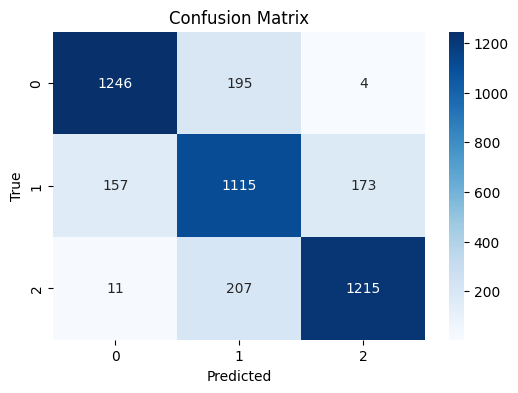

Top Features:
           feature  importance
14            lat    0.260535
2     sqft_living    0.127927
8           grade    0.082038
16  sqft_living15    0.075557
9      sqft_above    0.068494
15           long    0.066157
3        sqft_lot    0.052790
17     sqft_lot15    0.052714
13        zipcode    0.050984
11       yr_built    0.049824


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train the classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_resampled, y_resampled)

# Predict on the test set
y_pred = clf.predict(X_test)

# Evaluate performance
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Visualize Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Feature Importance
importances = clf.feature_importances_
features = X.columns
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("Top Features:\n", feature_importance_df.head(10))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 2.7 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.4
    Uninstalling xgboost-2.1.4:
      Successfully uninstalled xgboost-2.1.4
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88      1445
           1       0.76      0.79      0.78      1445
           2       0.88      0.88      0.88      1433

    accuracy                           0.85      4323
   macro avg       0.85      0.85      0.85      4323
weighted avg       0.85      0.85      0.85      4323

XGBoost Confusion Matrix:
 [[1260  181    4]
 [ 139 1136  170]
 [   4  168 1261]]


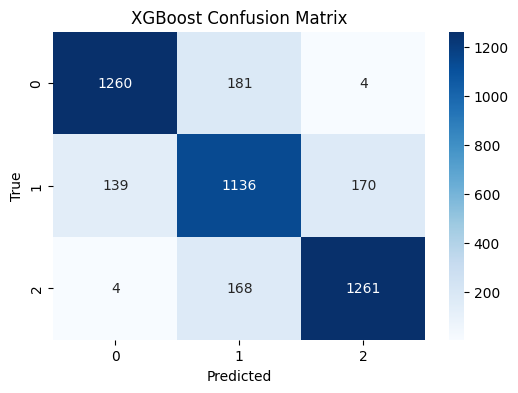

XGBoost Top Features:
           feature  importance
8           grade    0.281195
2     sqft_living    0.166385
14            lat    0.145962
6            view    0.061098
15           long    0.039218
7       condition    0.036977
16  sqft_living15    0.031416
13        zipcode    0.028856
3        sqft_lot    0.027762
9      sqft_above    0.025506


In [ ]:
# Install xgboost
!pip install xgboost==1.7.6

# %%
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train the XGBoost classifier
xgb_clf = XGBClassifier(random_state=42)
xgb_clf.fit(X_resampled, y_resampled)

# Predict on the test set
y_pred_xgb = xgb_clf.predict(X_test)

# Evaluate performance
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("XGBoost Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

# Visualize Confusion Matrix for XGBoost
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Feature Importance for XGBoost
importances_xgb = xgb_clf.feature_importances_
features_xgb = X.columns
feature_importance_df_xgb = pd.DataFrame({
    'feature': features_xgb,
    'importance': importances_xgb
}).sort_values(by='importance', ascending=False)

print("XGBoost Top Features:\n", feature_importance_df_xgb.head(10))

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Calculate Accuracy for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

# Calculate Accuracy for XGBoost
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")

# Calculate ROC AUC for Random Forest (One-vs-Rest)
# Binarize the test labels for multi-class AUC
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])
# Get predicted probabilities for each class
y_pred_proba_rf = clf.predict_proba(X_test)

# Compute ROC AUC for each class
roc_auc_per_class_rf = roc_auc_score(y_test_binarized, y_pred_proba_rf, average=None)
print(f"Random Forest ROC AUC (per class): {roc_auc_per_class_rf}")

# Compute macro-average ROC AUC
roc_auc_macro_avg_rf = roc_auc_score(y_test_binarized, y_pred_proba_rf, average='macro')
print(f"Random Forest ROC AUC (macro average): {roc_auc_macro_avg_rf:.4f}")


# Calculate ROC AUC for XGBoost (One-vs-Rest)
y_pred_proba_xgb = xgb_clf.predict_proba(X_test)

# Compute ROC AUC for each class
roc_auc_per_class_xgb = roc_auc_score(y_test_binarized, y_pred_proba_xgb, average=None)
print(f"XGBoost ROC AUC (per class): {roc_auc_per_class_xgb}")

# Compute macro-average ROC AUC
roc_auc_macro_avg_xgb = roc_auc_score(y_test_binarized, y_pred_proba_xgb, average='macro')
print(f"XGBoost ROC AUC (macro average): {roc_auc_macro_avg_xgb:.4f}")

Random Forest Accuracy: 0.8272
XGBoost Accuracy: 0.8459
Random Forest ROC AUC (per class): [0.97492864 0.91023983 0.97118961]
Random Forest ROC AUC (macro average): 0.9521
XGBoost ROC AUC (per class): [0.97728743 0.9215247  0.97609125]
XGBoost ROC AUC (macro average): 0.9583


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define a grid of hyperparameters to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the grid search to the resampled training data
grid_search.fit(X_resampled, y_resampled)

# Print the best hyperparameters and the corresponding best score
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Get the best model
best_clf = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_tuned = best_clf.predict(X_test)
print("Tuned Random Forest Classification Report:\n", classification_report(y_test, y_pred_tuned))

Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best Cross-Validation Accuracy: 0.8424147740591158
Tuned Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88      1445
           1       0.74      0.78      0.76      1445
           2       0.87      0.85      0.86      1433

    accuracy                           0.83      4323
   macro avg       0.83      0.83      0.83      4323
weighted avg       0.83      0.83      0.83      4323



Model Performance Comparison:
              Metric  Random Forest   XGBoost
0           Accuracy       0.827203  0.845940
1  Macro Avg ROC AUC       0.952119  0.958301


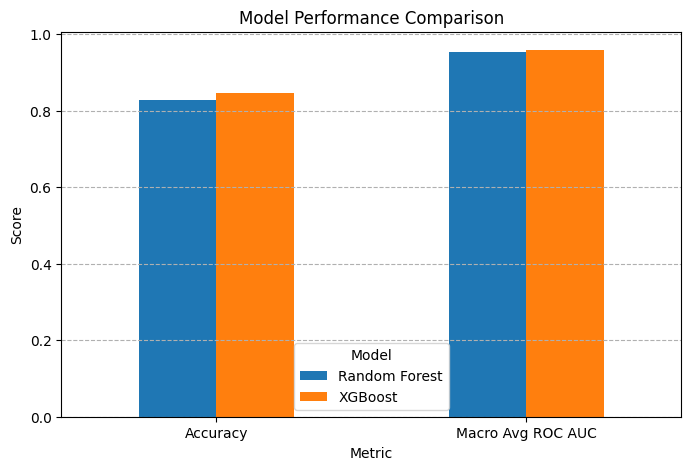

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

    # Assuming you have calculated these values
accuracy_rf = accuracy_score(y_test, y_pred)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
roc_auc_macro_avg_rf = roc_auc_score(y_test_binarized, y_pred_proba_rf, average='macro')
roc_auc_macro_avg_xgb = roc_auc_score(y_test_binarized, y_pred_proba_xgb, average='macro')

metrics_data = {
        'Metric': ['Accuracy', 'Macro Avg ROC AUC'],
        'Random Forest': [accuracy_rf, roc_auc_macro_avg_rf],
        'XGBoost': [accuracy_xgb, roc_auc_macro_avg_xgb]
    }
metrics_df = pd.DataFrame(metrics_data)

print("Model Performance Comparison:")
print(metrics_df)

    # Optional: Create a bar plot for comparison
metrics_df.set_index('Metric').plot(kind='bar', figsize=(8, 5))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--')
plt.show()

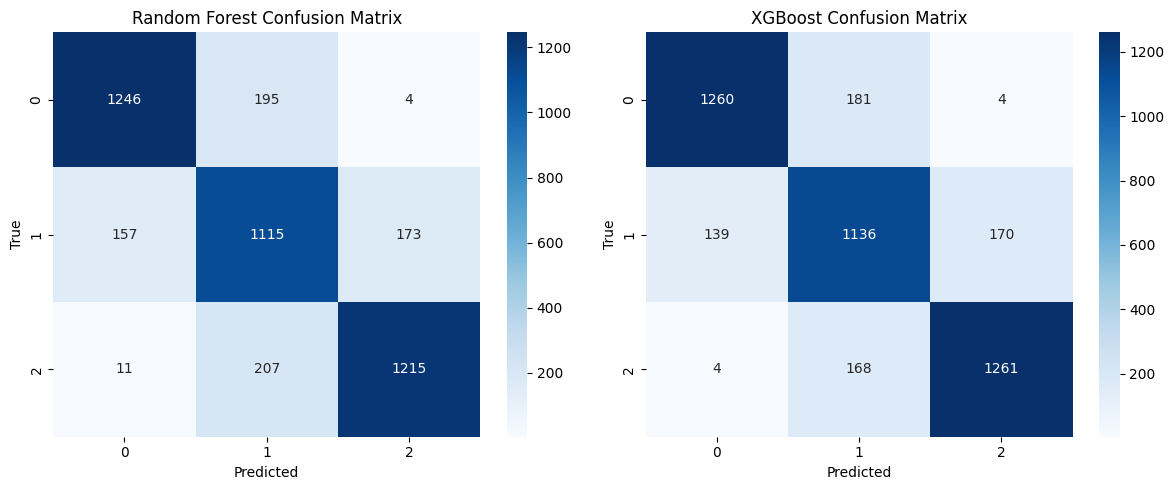

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

    # Assuming you have calculated the confusion matrices
cm_rf = confusion_matrix(y_test, y_pred)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Random Forest Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("XGBoost Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

<ipython-input-25-aac9f40f1e96>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10), ax=axes[0], palette='viridis')
<ipython-input-25-aac9f40f1e96>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df_xgb.head(10), ax=axes[1], palette='viridis')


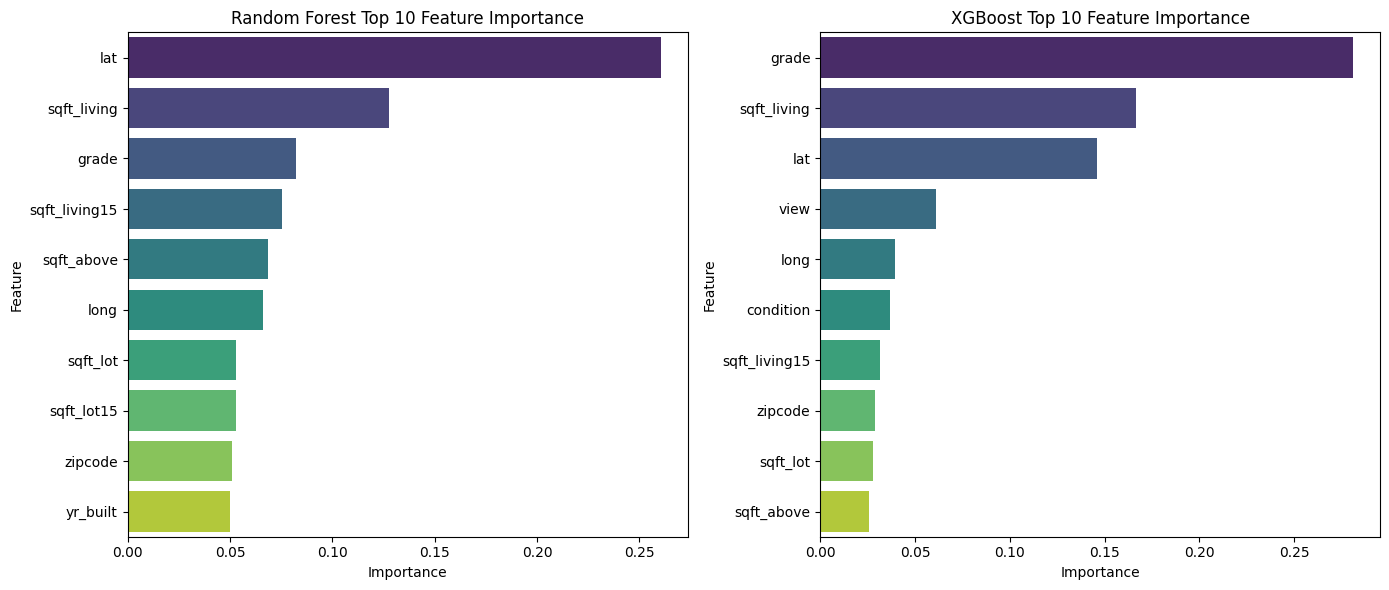

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

    # Assuming you have the feature importance dataframes
    # feature_importance_df from Random Forest
    # feature_importance_df_xgb from XGBoost

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot for Random Forest
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10), ax=axes[0], palette='viridis')
axes[0].set_title('Random Forest Top 10 Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature')

    # Plot for XGBoost
sns.barplot(x='importance', y='feature', data=feature_importance_df_xgb.head(10), ax=axes[1], palette='viridis')
axes[1].set_title('XGBoost Top 10 Feature Importance')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()